In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
rng = np.random.default_rng(42)
n = 200

surface  = rng.integers(3, 16, n)    # surface en dizaines de m² (30 à 150 m²)
chambres = rng.integers(1, 5, n)     # 1 à 4 chambres
age      = rng.integers(0, 5, n)     # âge en dizaines d'années (0 à 40 ans)
bruit    = rng.integers(-5, 6, n)    # petit écart aléatoire (−5 à +5)

# Le "vrai" prix : 20 par dizaine de m², +10 par chambre, −5 par dizaine d'années, +30 de base
prix = 20 * surface + 10 * chambres - 5 * age + 30 + bruit    # en milliers de TND

df = pd.DataFrame({"surface": surface, "chambres": chambres, "age": age, "prix": prix})
df.head()

,surface,chambres,age,prix
0,4,2,4,111
1,13,4,3,318
2,11,2,1,268
3,8,3,4,196
4,8,2,2,204


surface     0.98
chambres    0.13
age        -0.19
prix        1.00
Name: prix, dtype: float64


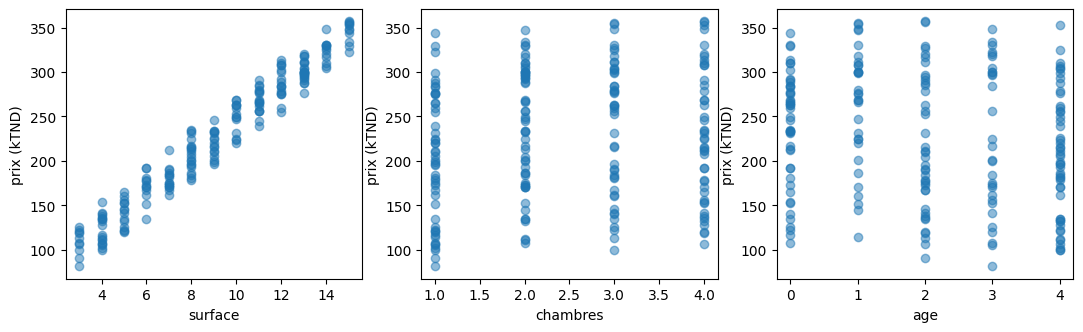

In [5]:
print(df.corr().round(2)["prix"])      # matrice de corrélation pour voir le lien entre chaque variable et le prix

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a, col in zip(ax, ["surface", "chambres", "age"]):
    a.scatter(df[col], df["prix"], alpha=0.5)
    a.set_xlabel(col); a.set_ylabel("prix (kTND)")
plt.show()

In [6]:
X = df[["surface", "chambres", "age"]]    # 3 colonnes d'entrée
y = df["prix"]                            # ce qu'on prédit

In [7]:
# 1er découpage : on met 20 % de côté pour le test
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2e découpage : sur les 80 % restants
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print("train :", len(X_train), "| validation :", len(X_val), "| test :", len(X_test))

train : 120 | validation : 40 | test : 40


In [8]:
modele = LinearRegression()
modele.fit(X_train, y_train)

for nom, coef in zip(X.columns, modele.coef_):
    print(f"poids de {nom:8} = {coef:.2f}")
print(f"biais b = {modele.intercept_:.2f}")

poids de surface  = 20.03
poids de chambres = 9.80
poids de age      = -5.30
biais b = 31.30


In [9]:
for nom, (A, b) in {"train": (X_train, y_train),
                    "validation": (X_val, y_val),
                    "test": (X_test, y_test)}.items():
    p = modele.predict(A)
    print(f"{nom:10} MSE = {mean_squared_error(b, p):6.2f} | "
          f"MAE = {mean_absolute_error(b, p):.2f} | R² = {r2_score(b, p):.3f}")

train      MSE =   8.63 | MAE = 2.44 | R² = 0.998
validation MSE =   9.38 | MAE = 2.63 | R² = 0.998
test       MSE =  11.95 | MAE = 3.12 | R² = 0.998


In [10]:
# Modèle A : les 3 variables       Modèle B : la surface seule
modele_B = LinearRegression().fit(X_train[["surface"]], y_train)

p_A = modele.predict(X_val)
p_B = modele_B.predict(X_val[["surface"]])
print(f"Modèle A (3 variables)  : MSE validation = {mean_squared_error(y_val, p_A):.2f}")
print(f"Modèle B (surface seule): MSE validation = {mean_squared_error(y_val, p_B):.2f}")

Modèle A (3 variables)  : MSE validation = 9.38
Modèle B (surface seule): MSE validation = 184.51


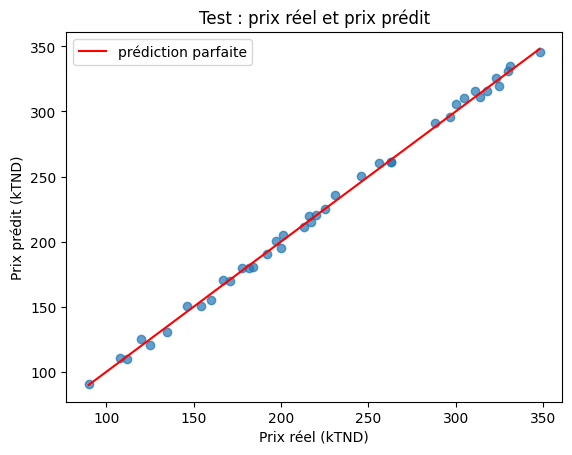

In [11]:
p_test = modele.predict(X_test)
plt.scatter(y_test, p_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", label="prédiction parfaite")
plt.xlabel("Prix réel (kTND)"); plt.ylabel("Prix prédit (kTND)")
plt.title("Test : prix réel et prix prédit"); plt.legend()
plt.show()

In [12]:
nouveau = pd.DataFrame({"surface": [7], "chambres": [2], "age": [2]})   # 70 m², 2 chambres, 20 ans
print(f"Prix prédit : {modele.predict(nouveau)[0]:.0f} milliers de TND")

Prix prédit : 180 milliers de TND


### Interface Interactive pour Tester le Modèle



In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Création des composants de l'interface (widgets)
slider_surface = widgets.IntSlider(value=7, min=3, max=20, step=1, description='Surface (x10 m²):')
slider_chambres = widgets.IntSlider(value=2, min=1, max=6, step=1, description='Chambres:')
slider_age = widgets.IntSlider(value=2, min=0, max=10, step=1, description='Âge (x10 ans):')

button_predict = widgets.Button(description="Estimer le prix", button_style='success', icon='calculator')
output_result = widgets.Output()

def calculer_prediction(b):
    with output_result:
        clear_output()
        # Récupération des valeurs des widgets
        surf = slider_surface.value
        ch = slider_chambres.value
        ag = slider_age.value

        # Création du DataFrame pour le modèle
        input_data = pd.DataFrame({"surface": [surf], "chambres": [ch], "age": [ag]})

        # Prédiction
        prix_predit = modele.predict(input_data)[0]

        # Affichage du résultat
        print(f"🏠 Caractéristiques : {surf*10} m², {ch} chambre(s), {ag*10} ans")
        print(f"💰 Prix estimé : {prix_predit:.2f} milliers de TND ({prix_predit * 1000:,.0f} TND)")

# Associer le clic du bouton à la fonction de calcul
button_predict.on_click(calculer_prediction)

# Affichage de l'interface
layout = widgets.VBox([
    widgets.HTML(value="<h4>Saisir les caractéristiques de la maison :</h4>"),
    slider_surface,
    slider_chambres,
    slider_age,
    widgets.Box([button_predict], layout=widgets.Layout(margin='10px 0px')),
    output_result
])

display(layout)
# Lancer une première estimation par défaut
calculer_prediction(None)